# Fake New Dectection

In [1]:
#import tensorflow as tf
#from tensorflow.python.client import device_lib
#tf.test.gpu_device_name()

#device_lib.list_local_devices()

ModuleNotFoundError: No module named 'tensorflow'

In [2]:
import numpy as np
import pandas as pd
import re,string,unicodedata
import os

# NLP Libs
import nltk
from nltk.corpus import stopwords
#from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud,STOPWORDS
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize,sent_tokenize
#from bs4 import BeautifulSoup

from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

#ML Algos
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

In [3]:
#from google.colab import drive
#drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Import our data

df=pd.read_csv('./fake-news-kaggleTrump/train.csv')
#df=pd.read_csv("/content/drive/MyDrive/trainData/dataSet1/train.csv")


# Data Analysis

In [4]:
print(df.shape)


(20800, 5)


In [5]:
df.columns

Index(['id', 'title', 'author', 'text', 'label'], dtype='object')

In [6]:
print(df.isnull().sum())

id           0
title      558
author    1957
text        39
label        0
dtype: int64


In [7]:
df.head()

,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1


In [8]:
df=df.fillna(' ')
df['total']=df['title']+' '+df['author']+' '+df['text']

In [9]:
df.head()

,id,title,author,text,label,total
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1,House Dem Aide: We Didn’t Even See Comey’s Let...
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0,"FLYNN: Hillary Clinton, Big Woman on Campus - ..."
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1,Why the Truth Might Get You Fired Consortiumne...
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1,15 Civilians Killed In Single US Airstrike Hav...
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1,Iranian woman jailed for fictional unpublished...


In [10]:
df = df.drop(['id','title','author','text'],axis = 1)

In [11]:
df.head()

,label,total
0,1,House Dem Aide: We Didn’t Even See Comey’s Let...
1,0,"FLYNN: Hillary Clinton, Big Woman on Campus - ..."
2,1,Why the Truth Might Get You Fired Consortiumne...
3,1,15 Civilians Killed In Single US Airstrike Hav...
4,1,Iranian woman jailed for fictional unpublished...


# Cleaning and preprocessing

In [13]:
#import nltk
#nltk.download('stopwords')
#nltk.download('punkt')
#nltk.download('stopwords')
#nltk.download('wordnet')
#nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [12]:
stop_words = stopwords.words('english')
lemmatizer=WordNetLemmatizer()
for index,row in df.iterrows():
    filter_sentence = ''

    sentence = row['total']
    sentence = re.sub(r'[^\w\s]','',sentence) #cleaning
    words = nltk.word_tokenize(sentence) #tokenization
    words = [w.lower() for w in words if not w in stop_words]  #stopwords removal

    for word in words:
        filter_sentence = filter_sentence + ' ' + str(lemmatizer.lemmatize(word)).lower()

    df.loc[index,'total'] = filter_sentence

In [13]:
df.head()

,label,total
0,1,house dem aide we didnt even see comeys lette...
1,0,flynn hillary clinton big woman campus breitb...
2,1,why truth might get you fired consortiumnewsc...
3,1,15 civilian killed in single u airstrike have...
4,1,iranian woman jailed fictional unpublished st...


In [15]:
#df.to_csv("./cleaned_data.csv")

# Vectorization

In [16]:
X_train = df['total']
Y_train = df['label']

In [17]:
#Feature extraction using count vectorization and tfidf.
count_vectorizer = CountVectorizer()
count_vectorizer.fit_transform(X_train)
freq_term_matrix = count_vectorizer.transform(X_train)
tfidf = TfidfTransformer(norm="l2")
tfidf.fit(freq_term_matrix)
tf_idf_matrix = tfidf.fit_transform(freq_term_matrix)

In [18]:
tf_idf_matrix

<20800x202501 sparse matrix of type '<class 'numpy.float64'>'
	with 5898836 stored elements in Compressed Sparse Row format>

# Modeling

In [19]:
test_counts = count_vectorizer.transform(df['total'].values)
test_tfidf = tfidf.transform(test_counts)

#split in samples
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(tf_idf_matrix, Y_train, random_state=0)

In [20]:
print(X_train.shape, X_test.shape)

(15600, 202501) (5200, 202501)


In [21]:
print(y_train.shape, y_test.shape)

(15600,) (5200,)


In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Training and Evaluation

Accuracy of Logistic classifier on training set: 1.00
Accuracy of Logistic classifier on test set: 0.98
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      2564
           1       0.97      0.98      0.98      2636

    accuracy                           0.98      5200
   macro avg       0.98      0.98      0.98      5200
weighted avg       0.98      0.98      0.98      5200



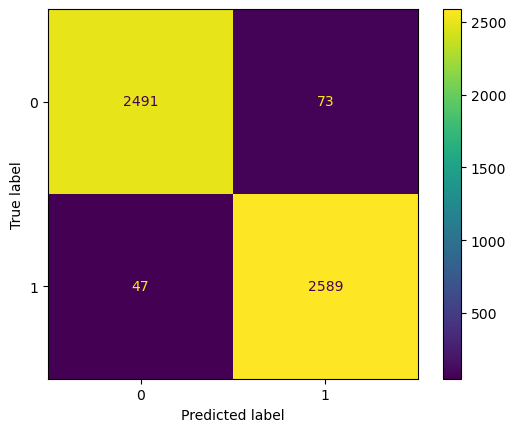

In [23]:
# DEMO
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(C=1e5)
logreg.fit(X_train, y_train)
pred = logreg.predict(X_test)
print('Accuracy of Logistic classifier on training set: {:.2f}'
     .format(logreg.score(X_train, y_train)))
print('Accuracy of Logistic classifier on test set: {:.2f}'
     .format(logreg.score(X_test, y_test)))
cm = confusion_matrix(y_test, pred)
cm
ConfusionMatrixDisplay.from_predictions(y_test,pred)
print(classification_report(y_test, pred))

In [24]:
def get_evaluation_result(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print('Accuracy of model classifier on training set: {:.2f}'
        .format(model.score(X_train, y_train)))
    print('Accuracy of model classifier on test set: {:.2f}'
        .format(model.score(X_test, y_test)))
    cm = confusion_matrix(y_test, pred)
    cm
    print(classification_report(y_test, pred))
    ConfusionMatrixDisplay.from_predictions(y_test,pred)

# 1. “lbfgs” Logistic Regression

Accuracy of model classifier on training set: 0.98
Accuracy of model classifier on test set: 0.96
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      2564
           1       0.95      0.96      0.96      2636

    accuracy                           0.96      5200
   macro avg       0.96      0.96      0.96      5200
weighted avg       0.96      0.96      0.96      5200



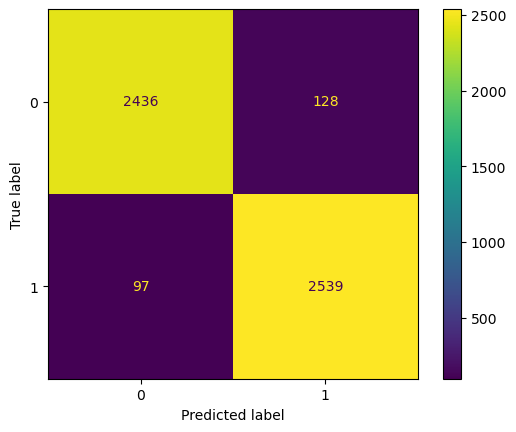

In [25]:
from sklearn.linear_model import LogisticRegression
lbfgs = LogisticRegression(solver='lbfgs')

get_evaluation_result(lbfgs, X_train, X_test, y_train, y_test)

# 2. “liblinear” Logistic Regression

Accuracy of model classifier on training set: 0.98
Accuracy of model classifier on test set: 0.96
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      2564
           1       0.95      0.96      0.96      2636

    accuracy                           0.96      5200
   macro avg       0.96      0.96      0.96      5200
weighted avg       0.96      0.96      0.96      5200



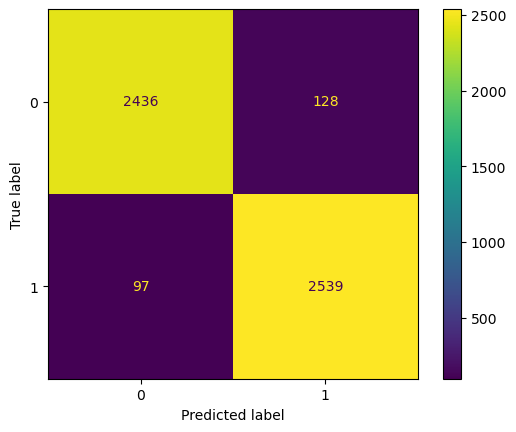

In [26]:
liblinear = LogisticRegression(solver='liblinear')

get_evaluation_result(liblinear, X_train, X_test, y_train, y_test)

# 3. “newton-cg” Logistic Regression

Accuracy of model classifier on training set: 0.98
Accuracy of model classifier on test set: 0.96
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      2564
           1       0.95      0.96      0.96      2636

    accuracy                           0.96      5200
   macro avg       0.96      0.96      0.96      5200
weighted avg       0.96      0.96      0.96      5200



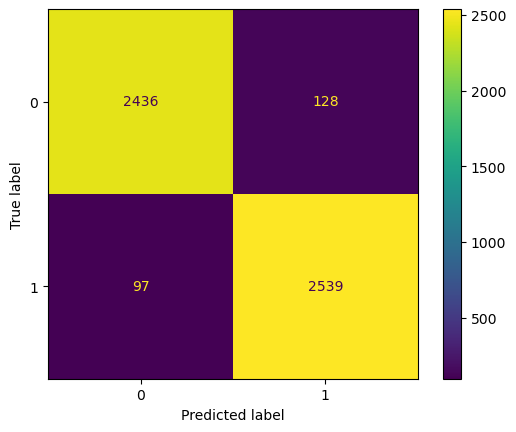

In [27]:
newton_cg = LogisticRegression(solver='newton-cg')

get_evaluation_result(newton_cg, X_train, X_test, y_train, y_test)

# 4. “newton-cholesky” Logistic Regression

Accuracy of model classifier on training set: 0.98
Accuracy of model classifier on test set: 0.96
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      2564
           1       0.95      0.96      0.96      2636

    accuracy                           0.96      5200
   macro avg       0.96      0.96      0.96      5200
weighted avg       0.96      0.96      0.96      5200



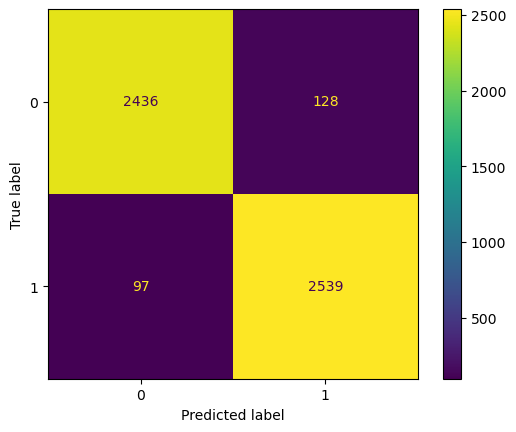

In [28]:
sag = LogisticRegression(solver='sag')

get_evaluation_result(sag, X_train, X_test, y_train, y_test)

In [29]:
#@title 5. Random Forest Logistic Regression

Accuracy of model classifier on training set: 1.00
Accuracy of model classifier on test set: 0.93
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      2564
           1       0.97      0.90      0.93      2636

    accuracy                           0.93      5200
   macro avg       0.94      0.94      0.93      5200
weighted avg       0.94      0.93      0.93      5200



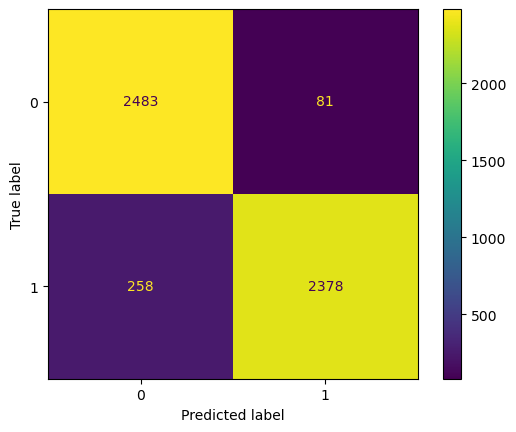

In [30]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)

get_evaluation_result(rf, X_train, X_test, y_train, y_test)

In [31]:
#@title 6. Perceptron

Accuracy of model classifier on training set: 1.00
Accuracy of model classifier on test set: 0.96
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      2564
           1       0.97      0.96      0.96      2636

    accuracy                           0.96      5200
   macro avg       0.96      0.96      0.96      5200
weighted avg       0.96      0.96      0.96      5200



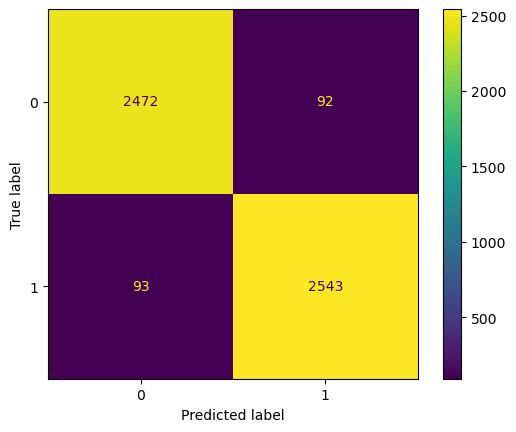

In [32]:
from sklearn.linear_model import Perceptron

perceptron = Perceptron(max_iter=1000, eta0=0.1, random_state=0)
get_evaluation_result(perceptron, X_train, X_test, y_train, y_test)

In [33]:
#@title 7. RidgeClassifier

Accuracy of model classifier on training set: 1.00
Accuracy of model classifier on test set: 0.97
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      2564
           1       0.97      0.98      0.98      2636

    accuracy                           0.97      5200
   macro avg       0.97      0.97      0.97      5200
weighted avg       0.97      0.97      0.97      5200



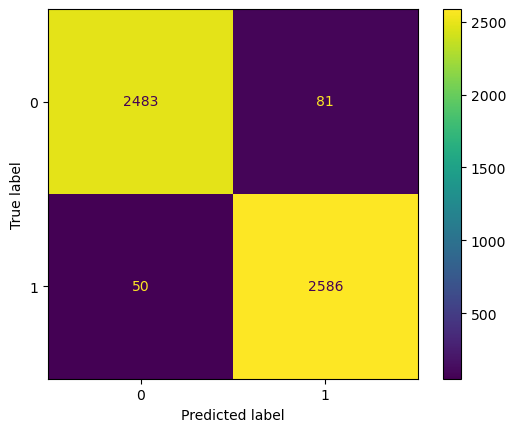

In [34]:
from sklearn.linear_model import RidgeClassifier
ridge_classifier = RidgeClassifier(alpha=1.0, solver='auto', random_state=0)
get_evaluation_result(ridge_classifier, X_train, X_test, y_train, y_test)

In [35]:
#@title 8. CatBoostClassifier

Accuracy of model classifier on training set: 0.98
Accuracy of model classifier on test set: 0.97
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2564
           1       0.97      0.97      0.97      2636

    accuracy                           0.97      5200
   macro avg       0.97      0.97      0.97      5200
weighted avg       0.97      0.97      0.97      5200



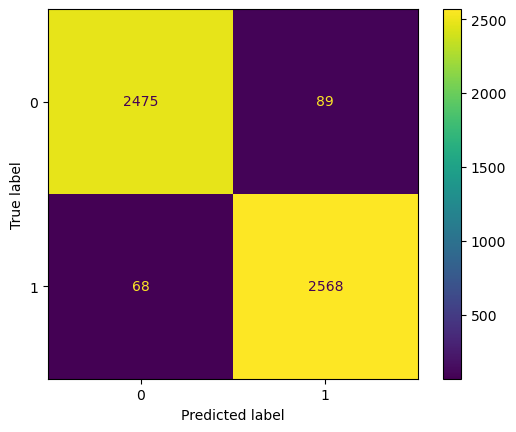

In [38]:
from catboost import CatBoostClassifier
# Create a CatBoostClassifier instance with specified hyperparameters
catboost_classifier = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6, loss_function='Logloss', verbose=0)

get_evaluation_result(catboost_classifier, X_train, X_test, y_train, y_test)

In [ ]:
#@title 9. NearestCentroidClassifier

Accuracy of model classifier on training set: 0.86
Accuracy of model classifier on test set: 0.85
              precision    recall  f1-score   support

           0       0.93      0.75      0.83      2564
           1       0.79      0.95      0.86      2636

    accuracy                           0.85      5200
   macro avg       0.86      0.85      0.85      5200
weighted avg       0.86      0.85      0.85      5200



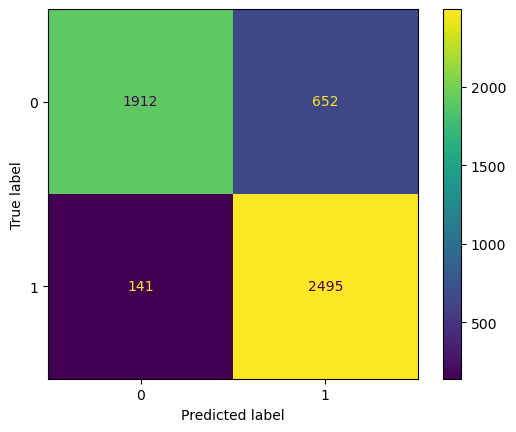

In [39]:
from sklearn.neighbors import NearestCentroid
ncc = NearestCentroid()

get_evaluation_result(ncc, X_train, X_test, y_train, y_test)

In [40]:
#@title 10. Stochastic Gradient Descent (SGDClassifier)

Accuracy of model classifier on training set: 0.99
Accuracy of model classifier on test set: 0.97
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2564
           1       0.97      0.97      0.97      2636

    accuracy                           0.97      5200
   macro avg       0.97      0.97      0.97      5200
weighted avg       0.97      0.97      0.97      5200



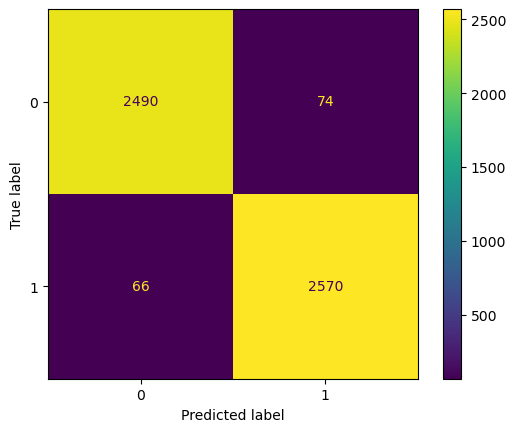

In [40]:
from sklearn.linear_model import SGDClassifier
sgd_classifier = SGDClassifier()

get_evaluation_result(sgd_classifier, X_train, X_test, y_train, y_test)

In [41]:
#@title 11. SVC (kernel=”linear”, C=0.025):

In [ ]:
from sklearn.svm import SVC
svm_lin = SVC(kernel="linear", C=0.025)

get_evaluation_result(svm_lin, X_train, X_test, y_train, y_test)

In [ ]:
#@title 12. SVC (gama=2, C=1)

In [ ]:
svm_rbf = SVC(kernel="rbf", gamma=2, C=1)

get_evaluation_result(svm_rbf, X_train, X_test, y_train, y_test)

In [ ]:
#@title 13. LinearSVC

In [ ]:
from sklearn.svm import LinearSVC
linear_svm_classifier = LinearSVC(C=1.0, random_state=0)

get_evaluation_result(linear_svm_classifier, X_train, X_test, y_train, y_test)

In [ ]:
#@title 14. SDGClassifier

In [ ]:
from sklearn.linear_model import SGDClassifier
# Create an SGDClassifier instance with hinge loss (SVM-like behavior), L2 regularization, and an initial learning rate (eta0)
sgd_classifier = SGDClassifier(loss='hinge', penalty='l2', alpha=0.0001, eta0=0.01, random_state=0, max_iter=1000)

get_evaluation_result(sgd_classifier, X_train, X_test, y_train, y_test)

In [ ]:
#@title 15. GaussianProcessClassifier

In [ ]:
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
# Create a GaussianProcessClassifier instance with an RBF kernel
kernel = 1.0 * RBF(1.0)
gpc_classifier = GaussianProcessClassifier(kernel=kernel, random_state=0)

get_evaluation_result(gpc_classifier, X_train, X_test, y_train, y_test)

In [ ]:
#@title 16. DecisionTreeClassifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_classifier = DecisionTreeClassifier(max_depth=None, min_samples_split=2, min_samples_leaf=1, random_state=0)

get_evaluation_result(dt_classifier, X_train, X_test, y_train, y_test)

In [ ]:
#@title 17.	Passive Aggressive (PassiveAggressiveClassifier)

In [ ]:
from sklearn.linear_model import PassiveAggressiveClassifier
pa_classifier = PassiveAggressiveClassifier(C=1.0, random_state=0, max_iter=1000)

get_evaluation_result(pa_classifier, X_train, X_test, y_train, y_test)

In [ ]:
#@title 18.	ExtraTreeClassifier

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
extra_tree_classifier = ExtraTreesClassifier(n_estimators=100, random_state=0)

get_evaluation_result(extra_tree_classifier, X_train, X_test, y_train, y_test)

In [ ]:
#@title 19.	HistGradiebtBoostingClassifier

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
histGBC = HistGradientBoostingClassifier()

get_evaluation_result(histGBC, X_train, X_test, y_train, y_test)

In [ ]:
#@title 20.	VotingClassifier

In [ ]:
from sklearn.ensemble import VotingClassifier

# Define individual classifiers
classifier1 = DecisionTreeClassifier()
classifier2 = SVC(probability=True)  # Use probability=True for soft voting
classifier3 = RandomForestClassifier()

# Create a VotingClassifier instance with soft voting
voting_classifier = VotingClassifier(estimators=[
    ('decision_tree', classifier1),
    ('svm', classifier2),
    ('random_forest', classifier3)
], voting='soft')  # You can also use 'hard' for hard voting

get_evaluation_result(voting_classifier, X_train, X_test, y_train, y_test)

In [ ]:
#@title 21. Stacked_generalization

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Define base models
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=0)),
    ('svc', SVC(probability=True)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=0))
]

# Define the meta-model
meta_model = LogisticRegression()

# Create a StackingClassifier instance
stacked_model = StackingClassifier(estimators=base_models, final_estimator=meta_model)

get_evaluation_result(stacked_model, X_train, X_test, y_train, y_test)

In [ ]:
#@title 22.	MLPClassifier:

In [ ]:
from sklearn.neural_network import MLPClassifier

# Create an MLPClassifier instance with specified architecture and hyperparameters
mlp_classifier = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', max_iter=1000, random_state=0)

get_evaluation_result(mlp_classifier, X_train, X_test, y_train, y_test)

In [ ]:
#@title 23.	BernoulliRBM:

In [ ]:
import lightgbm as lgb
lgb_classifier = lgb.LGBMClassifier(boosting_type='gbdt', num_leaves=31, learning_rate=0.05, n_estimators=100)

get_evaluation_result(lgb_classifier, X_train, X_test, y_train, y_test)

In [ ]:
#@title 24.	AdaBoostClassifier

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

adaboost_classifier = AdaBoostClassifier(n_estimators=50, learning_rate=1.0, random_state=0)

get_evaluation_result(adaboost_classifier, X_train, X_test, y_train, y_test)

In [ ]:
#@title 25.	GradientBoostingClassifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gb_classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=0)

get_evaluation_result(gb_classifier, X_train, X_test, y_train, y_test)

In [ ]:
#@title 26.	GaussianNB

In [ ]:
from sklearn.naive_bayes import GaussianNB
# Create a GaussianNB instance
gnb_classifier = GaussianNB()

get_evaluation_result(gnb_classifier, X_train, X_test, y_train, y_test)

In [ ]:
#@title 27.	Xgboost

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score

# Create a DMatrix for efficient data handling
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test)

# Define hyperparameters
params = {
    'objective': 'binary:logistic',
    'max_depth': 3,
    'eta': 0.1,
    'eval_metric': 'logloss'
}

# Train the XGBoost model
num_round = 100
xgboost_model = xgb.train(params, dtrain, num_round)

# Make predictions on the testing data
y_pred = xgboost_model.predict(dtest)
y_pred_binary = [1 if p > 0.5 else 0 for p in y_pred]

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred_binary)
print("Accuracy:", accuracy)

In [ ]:
#@title 28.	CategoricalNB

In [ ]:
from sklearn.naive_bayes import CategoricalNB

categorical_nb_classifier = CategoricalNB()
get_evaluation_result(categorical_nb_classifier, X_train, X_test, y_train, y_test)

In [ ]:
#@title 29.	ComplementNB

In [ ]:
from sklearn.naive_bayes import ComplementNB

# Create a ComplementNB instance
complement_nb_classifier = ComplementNB()
get_evaluation_result(complement_nb_classifier, X_train, X_test, y_train, y_test)

In [ ]:
#@title 29.	MultinomialNB

In [ ]:
from sklearn.naive_bayes import MultinomialNB

# Create a MultinomialNB instance
multinomial_nb_classifier = MultinomialNB()
get_evaluation_result(multinomial_nb_classifier, X_train, X_test, y_train, y_test)